# Atividade: Métodos Numéricos para Zeros de Funções


Este notebook é inspirado e desenvolvido sobre o trabalho feito pelo **Prof. Pedro Peixoto** (ppeixoto@usp.br). Foi modificado para atender outros assuntos do curso.

**Monitoria:** Eduardo
**Data:** Mar 2026

---

## Introdução
Neste notebook, vamos explorar a teoria e a prática de três métodos fundamentais para encontrar raízes de equações não lineares da forma $f(x) = 0$:
1.  **Método da Bisseção:** A abordagem do "dividir para conquistar".
2.  **Método do Ponto Fixo:** A arte de transformar $f(x)=0$ em $x=g(x)$.
3.  **Método de Newton:** O uso de derivadas para acelerar a busca.

O foco aqui é a **leitura crítica**: execute as células, analise os gráficos e compreenda os teoremas que garantem (ou não) a convergência.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Pacotes para gráficos
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Configurações globais de plotagem
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["lines.linewidth"] = 2
plt.style.use("seaborn-v0_8-whitegrid")

# 1. Método da Bisseção

### Intuição: O Jogo da Adivinhação
Imagine que eu escolhi um número inteiro entre 1 e 100 e você precisa adivinhar qual é. A cada chute, eu digo apenas se o meu número é "maior" ou "menor" que o seu. Qual a melhor estratégia? Chutar 50 (o meio). Se eu disser "menor", você elimina tudo acima de 50 e chuta 25.

O Método da Bisseção é exatamente isso, aplicado a funções contínuas.

### Requisitos Teóricos (Teorema de Bolzano)
Para funcionar, precisamos de:
1.  Uma função $f(x)$ **contínua** no intervalo $[a, b]$.
2.  Sinais opostos nas extremidades: $f(a) \cdot f(b) < 0$.

Se isso for verdade, o Teorema do Valor Intermediário (Bolzano) garante que existe pelo menos um $p \in (a, b)$ tal que $f(p) = 0$.

Veja um exemplo disso na próxima célula.




Análise do Intervalo [1, 2]:
f(1) = -2 (Negativo)
f(2) = 4 (Positivo)

>> Condição Satisfeita: f(a) e f(b) têm sinais opostos.
>> Pelo Teorema de Bolzano, EXISTE pelo menos uma raiz neste intervalo.


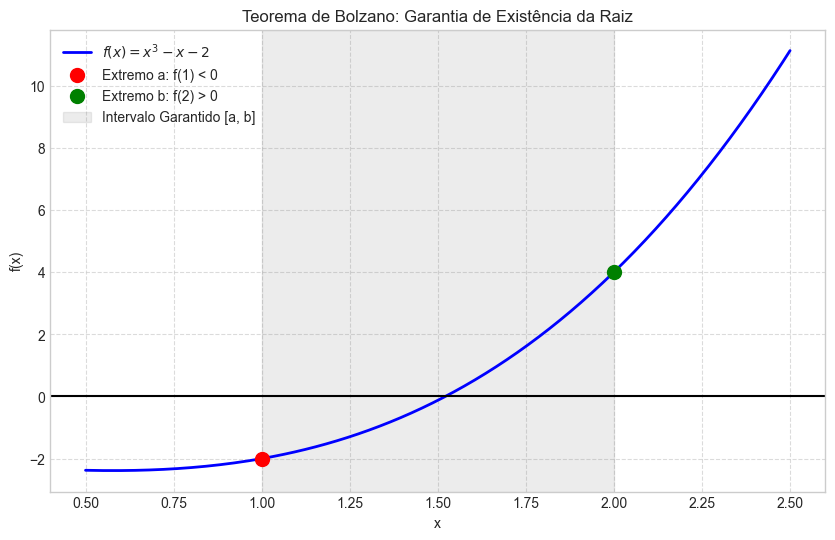

In [30]:
# 1. Definição da Função (Exemplo: x^3 - x - 2)
# É uma função polinomial, portanto contínua em todo seu domínio [Teorema 2.1]
f = lambda x: x**3 - x - 2
a, b = 1, 2  # Intervalo escolhido

# 2. Verificação Numérica do Teorema de Bolzano
fa, fb = f(a), f(b)

print(f"Análise do Intervalo [{a}, {b}]:")
print(f"f({a}) = {fa} (Negativo)")
print(f"f({b}) = {fb} (Positivo)")

# Checagem da condição f(a).f(b) < 0
if fa * fb < 0:
    print("\n>> Condição Satisfeita: f(a) e f(b) têm sinais opostos.")
    print(">> Pelo Teorema de Bolzano, EXISTE pelo menos uma raiz neste intervalo.")
else:
    print(">> A condição f(a)*f(b) < 0 não foi satisfeita. Escolha outro intervalo.")

# 3. Visualização Gráfica
plt.figure(figsize=(10, 6))

# Plot da curva
x = np.linspace(a - 0.5, b + 0.5, 200)
plt.plot(x, f(x), label=r"$f(x) = x^3 - x - 2$", color="blue", linewidth=2)

# Eixo X (Zero)
plt.axhline(0, color="black", linewidth=1.5)

# Destaque dos pontos extremos a e b
plt.plot(a, fa, "ro", markersize=10, label=f"Extremo a: f({a}) < 0")
plt.plot(b, fb, "go", markersize=10, label=f"Extremo b: f({b}) > 0")

# Destaque visual do intervalo onde a raiz deve estar
plt.axvspan(a, b, color="gray", alpha=0.15, label="Intervalo Garantido [a, b]")

# Estilização
plt.title("Teorema de Bolzano: Garantia de Existência da Raiz")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

### Implementação visual da bisseção

Veja como o intervalo de busca dimunui a cada iteração:



In [31]:
def previsao_iteracoes_bissecao(a, b, tol):
    return np.ceil(np.log2((b - a) / tol))

Iter  a          b          p (meio)   f(p)       Erro Max  
1     1.00000    2.00000    1.50000    -0.12500   0.50000   
2     1.50000    2.00000    1.75000    1.60938    0.25000   
3     1.50000    1.75000    1.62500    0.66602    0.12500   
4     1.50000    1.62500    1.56250    0.25220    0.06250   
5     1.50000    1.56250    1.53125    0.05911    0.03125   


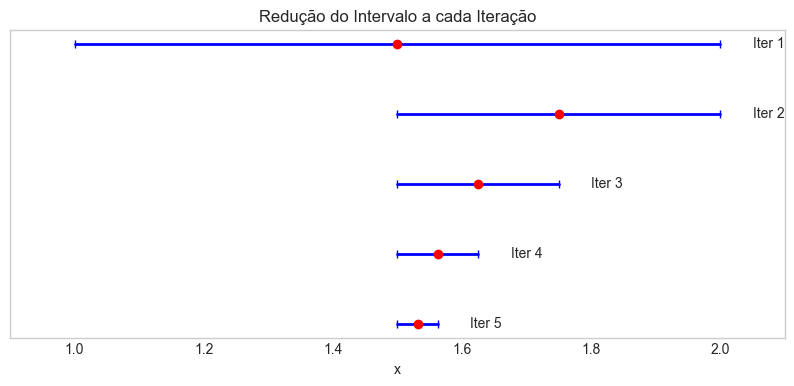

In [32]:
# Implementação Visual da Bisseção
def bissecao_visual(f, a, b, tol=1e-2):
    if f(a) * f(b) >= 0:
        return None

    historico = []

    print(
        f"{'Iter':<5} {'a':<10} {'b':<10} {'p (meio)':<10} {'f(p)':<10} {'Erro Max':<10}"
    )

    max_iter = int(previsao_iteracoes_bissecao(a, b, tol)) + 2  # Margem de segurança

    for i in range(max_iter):
        p = (a + b) / 2
        fp = f(p)
        erro = (b - a) / 2
        historico.append((a, b, p))

        print(f"{i+1:<5} {a:<10.5f} {b:<10.5f} {p:<10.5f} {fp:<10.5f} {erro:<10.5f}")

        if abs(fp) < 1e-15 or erro < tol:
            break

        if f(a) * fp > 0:
            a = p
        else:
            b = p

    return historico


f = lambda x: x**3 - x - 2
hist = bissecao_visual(f, 1, 2, tol=0.05)

# Visualizando a redução do intervalo
plt.figure(figsize=(10, 4))
y_fixed = 0
if hist is not None:
    for i, (ai, bi, pi) in enumerate(hist):
        plt.plot([ai, bi], [i, i], "b|-", lw=2)
        plt.plot(pi, i, "ro")
        plt.text(bi + 0.05, i, f"Iter {i+1}", va="center")

plt.title("Redução do Intervalo a cada Iteração")
plt.xlabel("x")
plt.yticks([])
plt.xlim(0.9, 2.1)
plt.gca().invert_yaxis()  # Iteração 1 no topo
plt.grid(axis="x")
plt.show()

### Análise de Erro

Uma das grandes vantagens da Bisseção é que sabemos exatamente o quão rápido o erro diminui. A cada iteração, o intervalo reduz pela metade.

**Teorema:** Suponha que $f \in C[a, b]$ e $f(a) \cdot f(b) < 0$. O método da Bisseção gera uma sequência $\{p_n\}$ aproximando o zero $p$, com a seguinte cota de erro:
$$ |p_n - p| \le \frac{b - a}{2^n}, \quad \text{para } n \ge 1. $$

Isso nos permite **determinar a priori** quantas iterações são necessárias para uma precisão $\epsilon$:
$$ n > \log_2\left(\frac{b-a}{\epsilon}\right) $$

In [33]:
# Exemplo: f(x) = x^3 - x - 2 no intervalo [1, 2] com precisão 1e-6
a, b = 1, 2
tol = 1e-6
n_necessario = previsao_iteracoes_bissecao(a, b, tol)
print(
    f"Para atingir erro < {tol} no intervalo [{a}, {b}], precisamos de {int(n_necessario)} iterações."
)

Para atingir erro < 1e-06 no intervalo [1, 2], precisamos de 20 iterações.


### Critérios de Parada e Dificuldades
Geralmente usamos três critérios:
1.  **Erro absoluto em x:** $|b - a| < \epsilon$ (Garantido pelo teorema).
2.  **Valor da função:** $|f(p)| < \epsilon$.
3.  **Erro relativo:** $|p_n - p_{n-1}| / |p_n| < \epsilon$.

**Cuidado:** Em funções muito "achatadas" (flat) perto da raiz (como $f(x) = x^{10}$), podemos ter $|f(p)|$ minúsculo mesmo estando longe da raiz $p=0$. Por isso, o critério do tamanho do intervalo é mais seguro na Bisseção.

A seguir, temos um exemplo de uma função achatada próxima a sua raíz.

Iter  x (aprox)    Crit1: Intervalo   Crit2: |f(x)|     
1     1.250000     7.50e-01           9.77e-04          
2     0.875000     3.75e-01           3.05e-05          
3     1.062500     1.88e-01           9.54e-07          
4     0.968750     9.38e-02           2.98e-08          
5     1.015625     4.69e-02           9.31e-10          
6     0.992188     2.34e-02           2.91e-11          
7     1.003906     1.17e-02           9.09e-13          
8     0.998047     5.86e-03           2.84e-14          
9     1.000977     2.93e-03           8.88e-16          
10    0.999512     1.46e-03           2.78e-17          


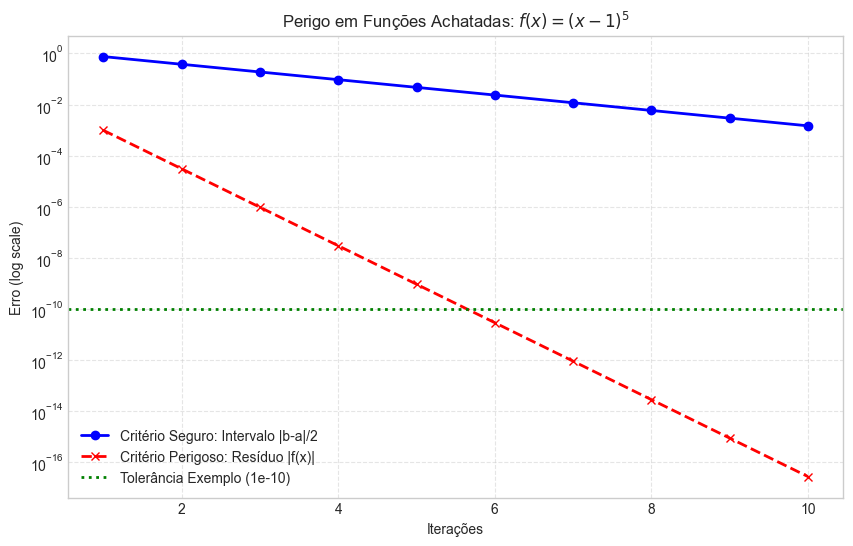

In [34]:
# 1. Nova Função "Achatada" (Flat) mas Válida
# Usamos uma potência ÍMPAR (5) para garantir que a função cruze o eixo X.
# Raiz exata = 1.0
f_flat = lambda x: (x - 1) ** 5

# Intervalo que garante troca de sinal (f(0) < 0 e f(2) > 0)
a, b = 0.5, 2.0


def bissecao_demonstracao(f, a, b, tol=1e-20, max_iter=10):
    # Verificação inicial (Teorema de Bolzano)
    if f(a) * f(b) >= 0:
        return None

    historico = []

    print(
        f"{'Iter':<5} {'x (aprox)':<12} {'Crit1: Intervalo':<18} {'Crit2: |f(x)|':<18}"
    )

    for k in range(max_iter):
        x = (a + b) / 2
        fx = f(x)

        # Critérios
        erro_intervalo = (b - a) / 2
        erro_residuo = abs(fx)

        historico.append([k + 1, x, erro_intervalo, erro_residuo])

        print(f"{k+1:<5} {x:<12.6f} {erro_intervalo:<18.2e} {erro_residuo:<18.2e}")

        # Bisseção Padrão
        if f(a) * fx < 0:
            b = x
        else:
            a = x

    return pd.DataFrame(
        historico, columns=["Iter", "Raiz", "Erro_Intervalo", "Erro_Residuo"]
    )


# Executar
df = bissecao_demonstracao(f_flat, a, b)

# Visualizar
if df is not None:
    plt.figure(figsize=(10, 6))

    # Plot em escala Logarítmica para ver as ordens de grandeza
    plt.semilogy(
        df["Iter"],
        df["Erro_Intervalo"],
        "b-o",
        label="Critério Seguro: Intervalo |b-a|/2",
    )
    plt.semilogy(
        df["Iter"],
        df["Erro_Residuo"],
        "r--x",
        label="Critério Perigoso: Resíduo |f(x)|",
    )

    # Linha de tolerância fictícia
    plt.axhline(1e-10, color="green", linestyle=":", label="Tolerância Exemplo (1e-10)")

    plt.title(r"Perigo em Funções Achatadas: $f(x) = (x-1)^5$")
    plt.xlabel("Iterações")
    plt.ylabel("Erro (log scale)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)

    # Anotação
    plt.annotate(
        "Olhe a diferença!\nO resíduo bate 10^-10 aqui,\nmas o erro real ainda é enorme",
        xy=(14, 1e-10),
        xytext=(20, 1e-5),
        arrowprops=dict(facecolor="black", shrink=0.05),
    )

    plt.show()

No exemplo acima, já na primeira iteração, o critério 2 de parada teria retornado x_1 = 1.25 como solução se o erro aceitável fosse da ordem 10^-3, o que claramente é uma péssima aproximação.


### Implementação

In [35]:
def bissecao(f, a, b, tol=1e-6, max_iter=100):
    """
    Implementação do Método da Bisseção para encontrar raízes de f(x) = 0.
    """
    # 1. Validação inicial (Teorema de Bolzano)
    if f(a) * f(b) >= 0:
        print("Erro: A função deve ter sinais opostos em a e b (f(a)*f(b) < 0).")
        return None

    print(
        f"{'Iter':<5} {'a':<12} {'b':<12} {'x (raiz)':<12} {'f(x)':<12} {'Erro (Intervalo)'}"
    )

    p = (a + b) / 2

    # 2. Loop iterativo
    for k in range(max_iter):
        # Cálculo do ponto médio
        p = (a + b) / 2
        fp = f(p)

        # Erro estimado (metade do tamanho do intervalo atual)
        erro = (b - a) / 2

        print(f"{k+1:<5} {a:<12.6f} {b:<12.6f} {p:<12.6f} {fp:<12.2e} {erro:.2e}")

        # 3. Critérios de Parada
        # Paramos se o intervalo for menor que a tolerância OU se acertarmos a raiz exata
        if erro < tol or fp == 0:
            return p

        # 4. Decisão de qual lado manter (onde ocorre a troca de sinal)
        if f(a) * fp < 0:
            b = p  # A raiz está entre [a, p]
        else:
            a = p  # A raiz está entre [p, b]

    print("Aviso: Número máximo de iterações atingido sem convergir totalmente.")
    return p

---
# 2. Método do Ponto Fixo

### O Conceito
Um número $p$ é um **ponto fixo** de uma função $g$ se $g(p) = p$.
A ideia deste método é transformar nosso problema original $f(x) = 0$ em um problema equivalente $x = g(x)$.

Exemplo: $x^3 - x - 2 = 0 \implies x^3 - 2 = x$. Aqui, $g(x) = x^3 - 2$.
Se encontrarmos onde $g(x)$ cruza a reta $y=x$, achamos a raiz.

### Teorema do Ponto Fixo
Nem toda $g(x)$ funciona. Antes de realizar uma busca pela raíz, é necessário saber se ela existe. O teorema a seguir garante existencia e unicidade sob algumas condições. Note que podem existir mais de um ponto fixo no intervalo, pois a unicidade só é valida quando (ii) é assegurado.

**(i) Existência:** Se $g \in C[a, b]$ e $g(x) \in [a, b]$ para todo $x$, existe pelo menos um ponto fixo.
**(ii) Unicidade e Convergência:** Se além disso, existir uma constante $k < 1$ tal que $|g'(x)| \le k$ (a derivada é pequena), então o ponto fixo é único e a iteração $p_{n} = g(p_{n-1})$ converge para ele.



### Múltiplos pontos fixos

Considere a função $g(x) = 1.5 * sin(x)$. Você consegue utilizar o Teorema do Ponto Fixo para garantir a existência de um ponto fixo? Essa função possui três pontos fixos no intervalo [-2,2].

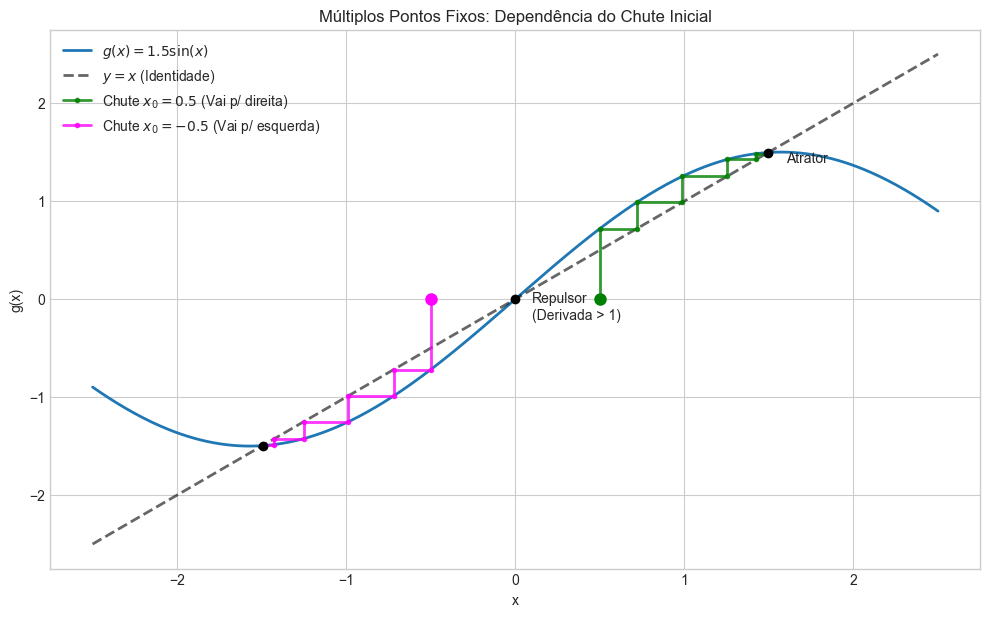

In [36]:
g_multi = lambda x: 1.5 * np.sin(x)

# Intervalo de visualização
x_vals = np.linspace(-2.5, 2.5, 400)

# 2. Configuração do Gráfico
plt.figure(figsize=(12, 7))
plt.plot(x_vals, g_multi(x_vals), label=r"$g(x) = 1.5 \sin(x)$", linewidth=2)
plt.plot(x_vals, x_vals, "k--", label="$y = x$ (Identidade)", alpha=0.6)

# Destacar os Pontos Fixos (Interseções)
pontos_fixos_reais = [-1.495, 0, 1.495]  # Valores aproximados
plt.scatter(pontos_fixos_reais, pontos_fixos_reais, color="black", zorder=5)
plt.text(0.1, -0.2, "Repulsor\n(Derivada > 1)", ha="left")
plt.text(1.6, 1.4, "Atrator", ha="left")


# 3. Função para traçar o caminho (Cobweb Plot)
def plotar_caminho(x0, cor, label):
    x_atual = x0
    path_x = [x_atual]
    path_y = [0]  # Começa do eixo x

    for _ in range(10):  # 10 iterações
        x_prox = g_multi(x_atual)

        # Sobe até a curva
        path_x.append(x_atual)
        path_y.append(x_prox)

        # Vai até a reta y=x
        path_x.append(x_prox)
        path_y.append(x_prox)

        x_atual = x_prox

    plt.plot(
        path_x, path_y, color=cor, marker=".", linestyle="-", alpha=0.8, label=label
    )
    # Marca o início
    plt.plot(x0, 0, "o", color=cor, markersize=8)


# 4. Executando dois cenários
# Cenário A: Começando um pouquinho à direita do zero
plotar_caminho(x0=0.5, cor="green", label="Chute $x_0 = 0.5$ (Vai p/ direita)")

# Cenário B: Começando um pouquinho à esquerda do zero
plotar_caminho(x0=-0.5, cor="magenta", label="Chute $x_0 = -0.5$ (Vai p/ esquerda)")

plt.title("Múltiplos Pontos Fixos: Dependência do Chute Inicial")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.legend()
plt.grid(True)
plt.show()

### Caso Patológico



Iter  x_k          Distância do alvo (x=1)
0     1.0500       0.0500
1     0.9250       0.0750
2     1.1125       0.1125
3     0.8312       0.1688
4     1.2531       0.2531


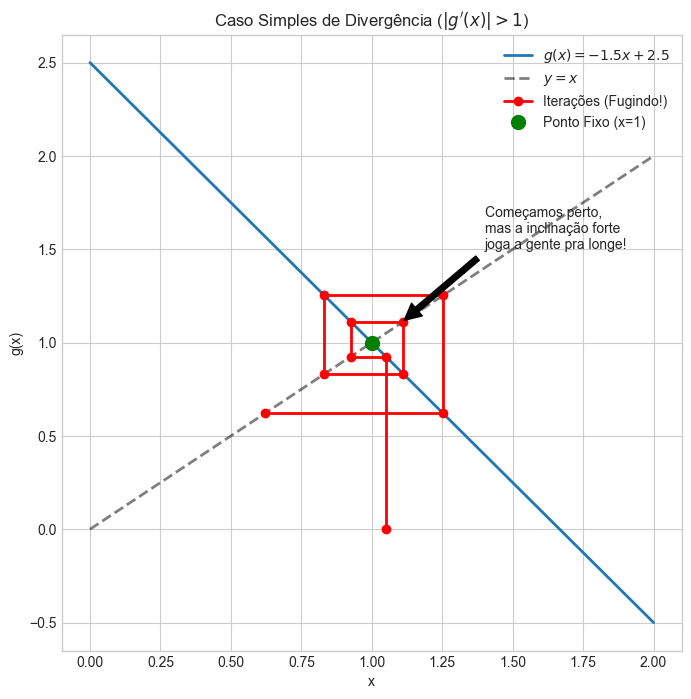

In [37]:
# 1. Função Simples e Patológica (Reta muito inclinada)
# g(x) = -1.5x + 2.5
# Ponto fixo exato é x = 1
# Derivada |g'(x)| = |-1.5| = 1.5 (> 1, logo DIVERGE)
g_simples = lambda x: -1.5 * x + 2.5

# 2. Configuração do Gráfico
plt.figure(figsize=(8, 8))
x_vals = np.linspace(0, 2, 100)
plt.plot(x_vals, g_simples(x_vals), label="$g(x) = -1.5x + 2.5$", lw=2)
plt.plot(x_vals, x_vals, "k--", label="$y = x$", alpha=0.5)

# 3. Executando o método (Cobweb)
# Vamos começar BEM PERTO da raiz (x=1), em x0=1.05
x_atual = 1.05
path_x = [x_atual]
path_y = [0]

print(f"{'Iter':<5} {'x_k':<12} {'Distância do alvo (x=1)'}")

for k in range(5):  # Poucas iterações pois explode rápido
    x_prox = g_simples(x_atual)

    # Desenha o caminho da teia
    path_x.append(x_atual)
    path_y.append(x_prox)  # Sobe até a curva
    path_x.append(x_prox)
    path_y.append(x_prox)  # Vai até y=x

    print(f"{k:<5} {x_atual:<12.4f} {abs(x_atual - 1):.4f}")
    x_atual = x_prox

# Plot do caminho
plt.plot(path_x, path_y, "r-o", label="Iterações (Fugindo!)")

# Destaques
plt.plot(1, 1, "go", markersize=10, label="Ponto Fixo (x=1)", zorder=5)
plt.title(r"Caso Simples de Divergência ($|g'(x)| > 1$)")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.legend()
plt.grid(True)

# Anotação explicando o visual
plt.annotate(
    "Começamos perto,\nmas a inclinação forte\njoga a gente pra longe!",
    xy=(1.1, 1.1),
    xytext=(1.4, 1.5),
    arrowprops=dict(facecolor="black", shrink=0.05),
)

plt.show()

Nesse caso, a derivada de $g$ faz o método divergir do ponto fixo.


---
# 3. Método de Newton

### Dedução Geométrica
O Método de Newton é baseado na **linearização** da função.
Dado um ponto $x_n$, aproximamos a curva $f(x)$ por sua reta tangente nesse ponto. Onde a tangente cruza o eixo $x$ será nosso próximo chute $x_{n+1}$.

A equação da reta tangente em $(x_n, f(x_n))$ é:
$$ y - f(x_n) = f'(x_n)(x - x_n) $$
Queremos encontrar onde $y=0$:
$$ 0 - f(x_n) = f'(x_n)(x_{n+1} - x_n) $$
Isolando $x_{n+1}$, chegamos na famosa iteração:
$$ x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} $$

### Uma implementação


In [38]:
# Método de Newton, com parâmetros:
# f   : função
# df  : derivada da função
# x0  : chute inicial
# n   : número de iterações máximo
# tol  : limitar para critério de parada


def newton(f, df, x0, n=100000, tol=10e-350):

    x = np.zeros(n + 1)  # o vetor é um pouco maior que preciso...
    # x = np.zeros(n+2, dtype=np.complex64) #vou permitir numeros complexos!
    x[0] = x0

    # Iteradas
    for i in range(n):

        # Se a derivada for muito perto de zero,... sem chances de continuar
        if np.abs(df(x[i])) < 10e-200:
            print("Derivada muito perto de zero...parando em", i, "iterações!")
            return x[: i + 1]  # Isso faz com o vetor devolvido vá até "i", incluso.

        # Aqui esta o método
        x[i + 1] = x[i] - f(x[i]) / df(x[i])

        # Critérios de parada
        if np.abs(x[i + 1] - x[i]) < tol:  # Diferença em x pequena
            print(
                "Parando pois variação entre iteradas está muito pequena!",
                i,
                "iterações!",
            )
            return x[
                : i + 2
            ]  # Devolvo até o elemento "i+1", incluso, pois este já foi computado

        if np.abs(f(x[i + 1])) < tol:  # f pequeno
            print("Parando pois a f está ficando muito pequena!", i, "iterações!")
            return x[
                : i + 2
            ]  # Devolvo até o elemento "i+1", incluso, pois este já foi computado

    print("Numero máximo de iterações atingido!", n)
    return x

### Interpretação geométrica das iterações

Iter 1: x = 2.000000 -> x_next = 1.636364
Iter 2: x = 1.636364 -> x_next = 1.530392
Iter 3: x = 1.530392 -> x_next = 1.521441


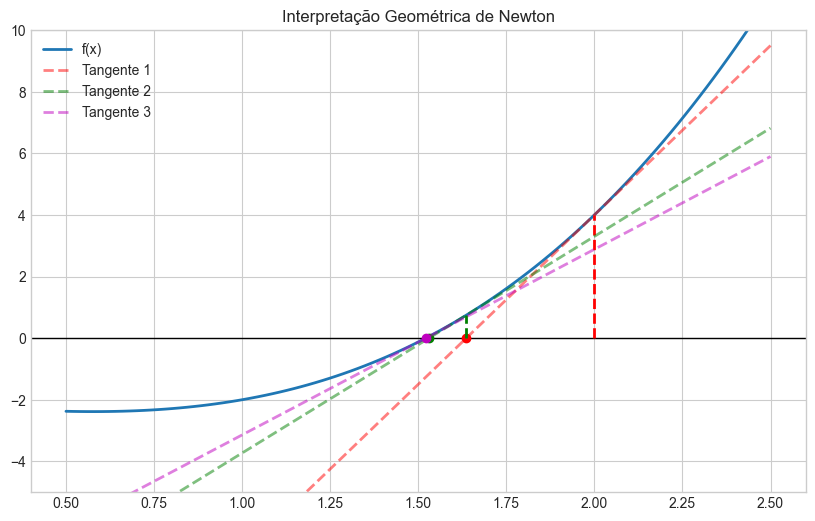

In [39]:
def newton_plot(f, df, x0, n_iter=3):
    x = np.linspace(0.5, 2.5, 100)
    plt.figure(figsize=(10, 6))
    plt.plot(x, f(x), label="f(x)", lw=2)
    plt.axhline(0, color="black", lw=1)

    xi = x0
    colors = ["r", "g", "m"]

    for i in range(n_iter):
        yi = f(xi)
        deriv = df(xi)

        # Tangente: y = m(x - xi) + yi
        tangente = lambda x: deriv * (x - xi) + yi

        # Próximo ponto
        xi_next = xi - yi / deriv

        # Desenhar linha vertical e tangente
        plt.plot([xi, xi], [0, yi], "--", color=colors[i])
        plt.plot(
            x, tangente(x), "--", color=colors[i], alpha=0.5, label=f"Tangente {i+1}"
        )
        plt.plot(xi_next, 0, "o", color=colors[i])

        print(f"Iter {i+1}: x = {xi:.6f} -> x_next = {xi_next:.6f}")
        xi = xi_next

    plt.title("Interpretação Geométrica de Newton")
    plt.ylim(-5, 10)
    plt.legend()
    plt.show()


f = lambda x: x**3 - x - 2
df = lambda x: 3 * x**2 - 1
newton_plot(f, df, x0=2.0)

### Convergência

Uma sequência $\{x_{n}\}_n$ convergente para $\bar{x}$ é convergente de ordem $\alpha \ge 1$ se,
$$\lim_{n \to \infty} \frac{|x_{n+1}-\bar{x}|}{|x_n-\bar{x}|^{\alpha}} = \lambda \in \mathbb{R}.$$

$\alpha$ é chamado de **ordem de convergência da sequência**.

É possível mostrar que se a sequência converge com ordem $\alpha$ para o valor $\bar{x}$, então
$$\lim_{n \to \infty} \frac{|x_{n+1}-\bar{x}|}{|x_n-\bar{x}|^{\alpha}} = \lim_{n \to \infty} \frac{|x_{n+1}-x_n|}{|x_n-x_{n-1}|^{\alpha}}.$$

É possível estimar a ordem de convergência de um método com base nas suas iterações. Vejamos. Para $n$ suficientemente grande
$$
\frac{|x_{n+1}-x_n|}{|x_n-x_{n-1}|^{\alpha}} \approx \lambda .
$$
Mas observe que também vale para $n-1$,
$$
\frac{|x_{n}-x_{n-1}|}{|x_{n-1}-x_{n-2}|^{\alpha}} \approx \lambda,
$$
logo podemos escrever que
$$
\frac{|x_{n}-x_{n-1}|}{|x_{n-1}-x_{n-2}|^{\alpha}} \approx \frac{|x_{n+1}-x_n|}{|x_n-x_{n-1}|^{\alpha}}
$$

de onde podemos tirar que
$$
\left(\frac{|x_n-x_{n-1}|}{|x_{n-1}-x_{n-2}|}\right)^{\alpha} \approx \frac{|x_{n+1}-x_n|}{|x_{n}-x_{n-1}|}
$$
e portanto
$$
\alpha \approx \frac  { \ln \left(\frac{|x_{n+1}-x_n|}{|x_{n}-x_{n-1}|}\right)}{\ln \left(\frac{|x_n-x_{n-1}|}{|x_{n-1}-x_{n-2}|}\right)}
$$

Ou seja, para calcular a ordem de convergência, basta usarmos informações de 4 iteradas da sequência, $x_{n-2},x_{n-1}, x_n, x_{n+1}$, para algum $n$ suficientemente grande.

In [40]:
# Recebe um vetor com as estimativas e retorna diversas estimativas de ordem
def ordem(x, eps=10e-8):
    n = x.size  # tamanho do vetor
    if x.size < 4:
        print("erro, poucos elementos")
        return 0

    # Vamos calcular a ordem para cada conjunto de 4 elementos da sequencia
    alpha_list = []
    for m in range(4, n):

        # Vamos evitar dividir por zero, então se as iteradas já mudam muito pouco, pare
        if np.abs(x[m - 1] - x[m - 2]) < eps:
            print("Ordem calculada com base na razão final: ", alpha_list[-1])
            return alpha_list

        # Calculo alpha com base nos elementos m, m-1, m-2, m-3
        alpha = np.log(np.abs((x[m] - x[m - 1]) / (x[m - 1] - x[m - 2]))) / np.log(
            np.abs((x[m - 1] - x[m - 2]) / (x[m - 2] - x[m - 3]))
        )

        # Adiciono alpha na lista de alphas calculados
        alpha_list.append(alpha)

    print("Ordem aproximada calculada com base na razão final: ", alpha_list[-1])
    return alpha_list

Vejamos um exemplo de cálculo de ordem com a função:

$$ f(x) = x^p -2$$

com $p=4$ partindo de $x_0=1$.

In [41]:
# Exemplo
p = 4
f = lambda x: x**p - 2
df = lambda x: p * x ** (p - 1)

root = newton(f, df, x0=1, tol=10e-300)
print(root)

# Calcula da ordem
ord = ordem(root)
print(ord)

Parando pois variação entre iteradas está muito pequena! 5 iterações!
[1.         1.25       1.1935     1.18923022 1.18920712 1.18920712
 1.18920712]
Ordem calculada com base na razão final:  2.000907559994399
[np.float64(2.0208678782147995), np.float64(2.000907559994399)]


### O método de newton para o caso complexo

Dado $z_0 \in \mathbb{C}$:

$$z_{i+1}=z_{i}-f(z)/f'(z) $$

O código é o mesmo de antes, só mudamos o tipo da variável "x"


In [42]:
# Método de Newton, com parâmetros:
# f   : função
# df  : derivada da função
# x0  : chute inicial
# n   : número de iterações máximo
# tol  : limitar para critério de parada
# stop : tipo de critério de parada ("f" default, "x")


def newton(f, df, x0, n=1000, tol=10e-5, stop="f"):

    # x = np.zeros(n+2) # o vetor é um pouco maior que preciso...
    x = np.zeros(n + 2, dtype=np.complex64)  # vou permitir numeros complexos!
    x[0] = x0

    i = 0
    # Iteradas
    for i in range(n):

        # Se a derivada for muito perto de zero,... sem chances de continuar
        if np.abs(df(x[i])) < 10e-20:
            print("derivada muito perto de zero...parando em", i, "iterações!")
            return x[: i + 1]

        # Aqui esta o método
        x[i + 1] = x[i] - f(x[i]) / df(x[i])

        # Critérios de parada
        if stop == "x":  # Diferença em x pequena
            if np.abs(x[i + 1] - x[i]) < tol:
                return x[: i + 2]

        else:  # stop == "f" # default # f pequeno
            if np.abs(f(x[i + 1])) < tol:
                return x[: i + 2]

    return x[: i + 1]

In [43]:
# Nossa função de interesse
f = lambda z: z**3 - 1
df = lambda z: 3 * z**2

# f = lambda z: z**4 - 1
# df = lambda z: 4*z**3

(-1-0.5j)
(-0.50666666-0.5466667j)
(-0.38328177-0.96271646j)
(-0.4810174-0.8551827j)
(-0.50049007-0.8660135j)
(-0.5000001-0.86602515j)



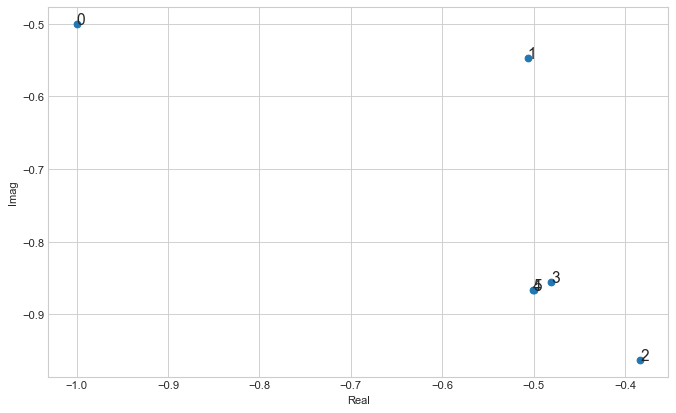

In [44]:
# Vamos chamar o nosso Newton!
z0 = -1 - 0.5j
root = newton(f, df, x0=z0, n=115)

# Plot das raizes
fig = plt.figure(figsize=(10, 6), dpi=80)
plt.plot(root.real, root.imag, "o")
for i, r in enumerate(root):
    print(r)
    plt.annotate(str(i), (root.real[i], root.imag[i]), fontsize=14)

plt.ylabel("Imag")
plt.xlabel("Real")
print()

##Fractais : A bacia de atração complexa

In [45]:
# Dominio [-a,a] x [-i*a,i*a]
a = 2

# Discretização do domínio em 2000 pontos
d = 1001j  # numero de pontos entre -a e a (inclusive)

# Malha de reais em R2
x, y = np.ogrid[-a:a:d, -a:a:d]  # Vetores

# Malha de complexos
z0 = x + 1j * y

print(z0.shape)
print(z0[:10, :10])

(1001, 1001)
[[-2.   -2.j    -2.   -1.996j -2.   -1.992j -2.   -1.988j -2.   -1.984j
  -2.   -1.98j  -2.   -1.976j -2.   -1.972j -2.   -1.968j -2.   -1.964j]
 [-1.996-2.j    -1.996-1.996j -1.996-1.992j -1.996-1.988j -1.996-1.984j
  -1.996-1.98j  -1.996-1.976j -1.996-1.972j -1.996-1.968j -1.996-1.964j]
 [-1.992-2.j    -1.992-1.996j -1.992-1.992j -1.992-1.988j -1.992-1.984j
  -1.992-1.98j  -1.992-1.976j -1.992-1.972j -1.992-1.968j -1.992-1.964j]
 [-1.988-2.j    -1.988-1.996j -1.988-1.992j -1.988-1.988j -1.988-1.984j
  -1.988-1.98j  -1.988-1.976j -1.988-1.972j -1.988-1.968j -1.988-1.964j]
 [-1.984-2.j    -1.984-1.996j -1.984-1.992j -1.984-1.988j -1.984-1.984j
  -1.984-1.98j  -1.984-1.976j -1.984-1.972j -1.984-1.968j -1.984-1.964j]
 [-1.98 -2.j    -1.98 -1.996j -1.98 -1.992j -1.98 -1.988j -1.98 -1.984j
  -1.98 -1.98j  -1.98 -1.976j -1.98 -1.972j -1.98 -1.968j -1.98 -1.964j]
 [-1.976-2.j    -1.976-1.996j -1.976-1.992j -1.976-1.988j -1.976-1.984j
  -1.976-1.98j  -1.976-1.976j -1.976-1.972j -

In [46]:
# Iterações de Newton em conjunto para todos os chutes iniciais!
niter = 200
eps = 1.0e-16
np.seterr(divide="ignore", invalid="ignore")

z = z0
for i in range(niter):
    dftmp = df(z)
    dftmp[np.abs(dftmp) < eps] = np.nan
    z -= f(z) / dftmp

In [47]:
# Saiu do domnínio?
z[np.isnan(z)] = 0.0 + 0j
z[np.abs(z.real) > a - eps] = 0.0 + 0j
z[np.abs(z.imag) > a - eps] = 0.0 + 0j
# print(np.angle(z))

# Raízes que achei
unique_roots = np.unique(z.round(decimals=2))
unique_roots = np.delete(unique_roots, (unique_roots == 0j).argmax())
root_list = []
print("Raízes que achei (aproximadas):")
for root in unique_roots:
    root_list.append((root.real, root.imag))
    print(root)

nroots = len(unique_roots)

Raízes que achei (aproximadas):
(-0.5-0.87j)
(-0.5+0.87j)
(1+0j)


In [48]:
# Transformar os valores das raízes imaginárias em cores!
zcol = np.zeros_like(z, dtype=np.int64)
tol = 0.01
for i, root in enumerate(unique_roots):
    zcol[np.abs(z - root) < tol] = i

# Inverte eixos para plots
zcol = zcol.swapaxes(0, 1)

# inverte ordem do eixo y (plotar de baixo para cima)
# zcol = zcol[:, ::-1]


# Cores das raízes
colors = [
    "g",
    "b",
    "r",
    "y",
    "m",
    "k",
]
cmap = ListedColormap(colors[:nroots])

print(zcol)

[[0 0 0 ... 2 2 2]
 [0 0 0 ... 2 2 2]
 [0 0 0 ... 2 2 2]
 ...
 [1 1 1 ... 2 2 2]
 [1 1 1 ... 2 2 2]
 [1 1 1 ... 2 2 2]]


Roots: -0.5 -0.87
Roots: -0.5 0.87
Roots: 1.0 0.0


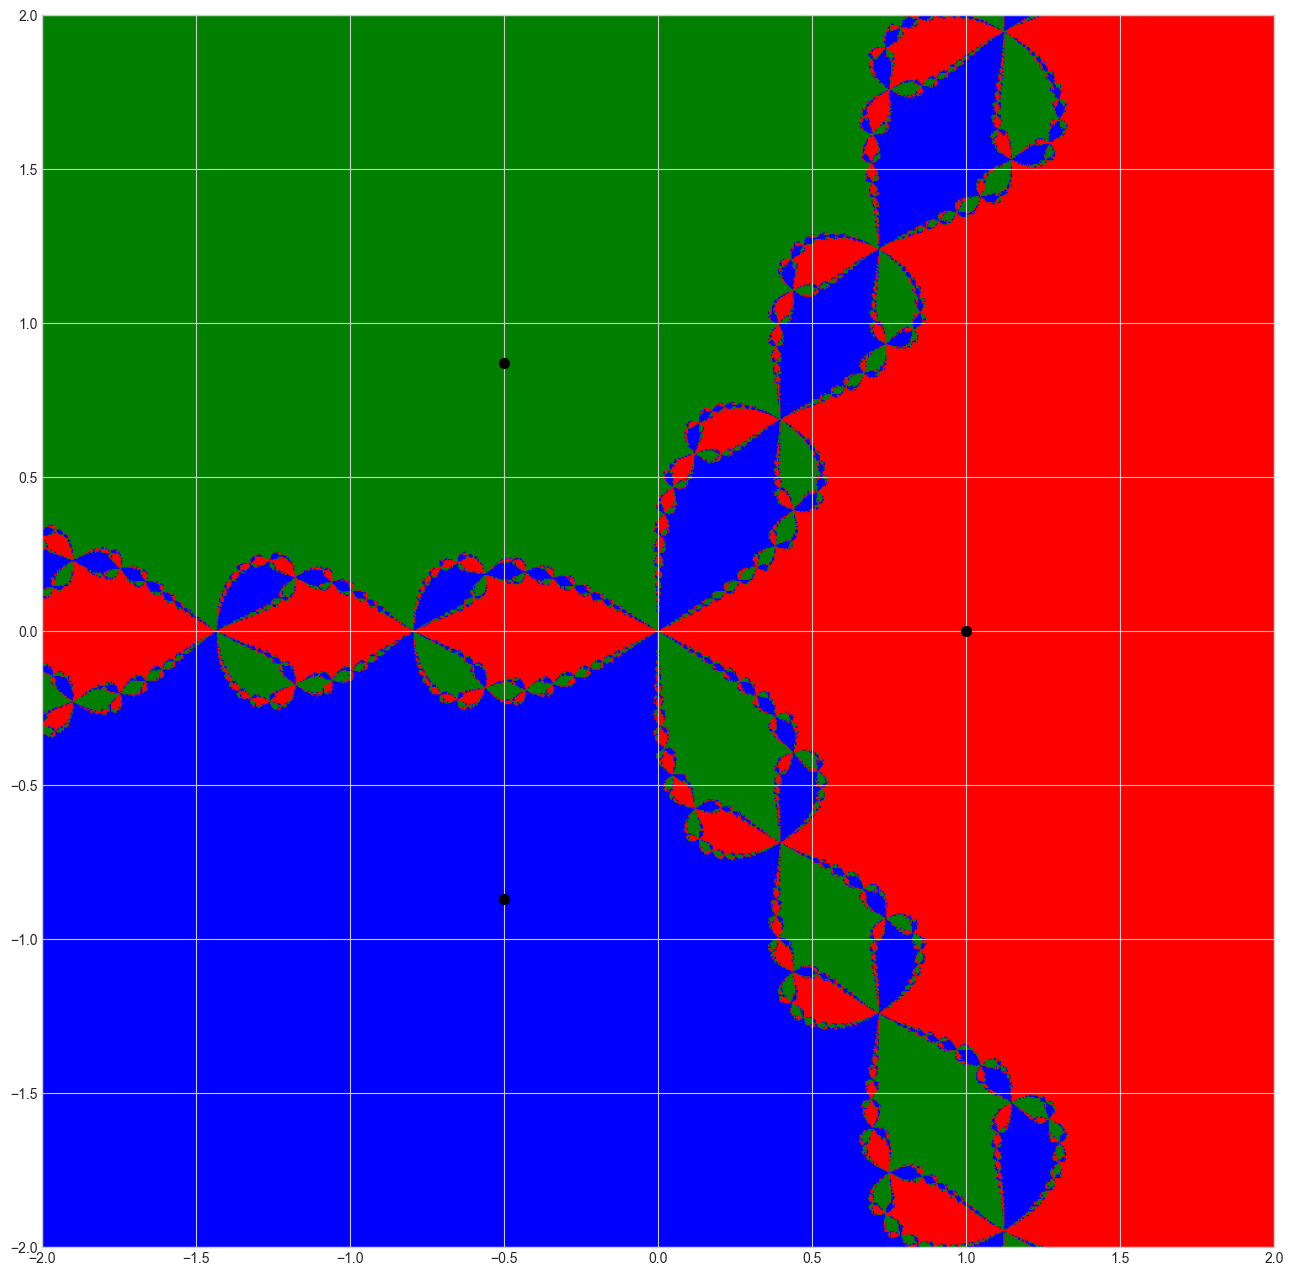

In [49]:
# Plot figure

plt.figure(figsize=(16, 16))
plt.imshow(zcol, cmap=cmap, extent=(-a, a, -a, a))
for x, y in root_list:
    print("Roots:", x, y)
    plt.scatter(x, y, s=50, c="black", marker="o")


# 🎯 Atividade Prática Final: O Duelo dos Métodos

Agora é sua vez de colocar a mão na massa. Vamos encontrar a raiz da função:
$$ f(x) = e^{-x} - x $$

Sabemos graficamente que a raiz está no intervalo $[0, 1]$.

### Tarefa 1: Bisseção
Use a função `bissecao` que definimos anteriormente para encontrar a raiz no intervalo $[0, 1]$ com tolerância de $10^{-6}$.
* **Pergunta:** Quantas iterações foram necessárias?

### Tarefa 2: Ponto Fixo
Para usar o ponto fixo, podemos isolar o $x$ de duas formas:
1.  **Forma A:** $x = e^{-x} \implies g_1(x) = e^{-x}$
2.  **Forma B:** $e^{-x} = x \implies -x = \ln(x) \implies g_2(x) = -\ln(x)$

Teste o método `ponto_fixo` com a **Forma A** (chute inicial 0.5). Funcionou?
Agora tente aplicar a **Forma B**. O que acontece se você tentar calcular $g_2(0.5)$? E a derivada $|g_2'(x)|$ perto da raiz?

### Tarefa 3: Newton
Use o método de `newton` para achar a raiz.
* Lembre-se: A derivada é $f'(x) = -e^{-x} - 1$.
* Compare o número de iterações do Newton com o da Bisseção.


# Tarefa 1:

In [50]:
f = lambda x: np.exp(-x) - x

raiz_bissecao = bissecao(f, 0, 1, tol=1e-6)

print(f"\nRaiz aproximada: {raiz_bissecao:.8f}")

Iter  a            b            x (raiz)     f(x)         Erro (Intervalo)
1     0.000000     1.000000     0.500000     1.07e-01     5.00e-01
2     0.500000     1.000000     0.750000     -2.78e-01    2.50e-01
3     0.500000     0.750000     0.625000     -8.97e-02    1.25e-01
4     0.500000     0.625000     0.562500     7.28e-03     6.25e-02
5     0.562500     0.625000     0.593750     -4.15e-02    3.12e-02
6     0.562500     0.593750     0.578125     -1.72e-02    1.56e-02
7     0.562500     0.578125     0.570312     -4.96e-03    7.81e-03
8     0.562500     0.570312     0.566406     1.16e-03     3.91e-03
9     0.566406     0.570312     0.568359     -1.91e-03    1.95e-03
10    0.566406     0.568359     0.567383     -3.75e-04    9.77e-04
11    0.566406     0.567383     0.566895     3.90e-04     4.88e-04
12    0.566895     0.567383     0.567139     7.24e-06     2.44e-04
13    0.567139     0.567383     0.567261     -1.84e-04    1.22e-04
14    0.567139     0.567261     0.567200     -8.84e-05

O número de iterações necessárias para atingir menos de 10e-6 de erro foi 20

# Tarefa 2:

In [51]:
def ponto_fixo(g, x0, tol=1e-6, max_iter=100):
    x = x0
    print(f"{'Iter':<5} {'x_old':<12} {'x_new':<12} {'Erro'}")

    for k in range(max_iter):
        x_new = g(x)

        erro = abs(x_new - x)
        print(f"{k+1:<5} {x:<12.6f} {x_new:<12.6f} {erro:.2e}")

        if erro < tol:
            return x_new

        x = x_new

    print("Número máximo de iterações atingido.")
    return x

In [52]:
# Forma A: g1(x) = e^(-x)
g1 = lambda x: np.exp(-x)
raiz_g1 = ponto_fixo(g1, x0=0.5)
print(f"Raiz (Forma A): {raiz_g1:.8f}")

Iter  x_old        x_new        Erro
1     0.500000     0.606531     1.07e-01
2     0.606531     0.545239     6.13e-02
3     0.545239     0.579703     3.45e-02
4     0.579703     0.560065     1.96e-02
5     0.560065     0.571172     1.11e-02
6     0.571172     0.564863     6.31e-03
7     0.564863     0.568438     3.58e-03
8     0.568438     0.566409     2.03e-03
9     0.566409     0.567560     1.15e-03
10    0.567560     0.566907     6.52e-04
11    0.566907     0.567277     3.70e-04
12    0.567277     0.567067     2.10e-04
13    0.567067     0.567186     1.19e-04
14    0.567186     0.567119     6.75e-05
15    0.567119     0.567157     3.83e-05
16    0.567157     0.567135     2.17e-05
17    0.567135     0.567148     1.23e-05
18    0.567148     0.567141     6.98e-06
19    0.567141     0.567145     3.96e-06
20    0.567145     0.567142     2.25e-06
21    0.567142     0.567144     1.27e-06
22    0.567144     0.567143     7.22e-07
Raiz (Forma A): 0.56714303


In [53]:
# Forma B: g2(x) = -ln(x)
g2 = lambda x: -np.log(x)
raiz_g2 = ponto_fixo(g2, x0=0.5, max_iter=10)

Iter  x_old        x_new        Erro
1     0.500000     0.693147     1.93e-01
2     0.693147     0.366513     3.27e-01
3     0.366513     1.003722     6.37e-01
4     1.003722     -0.003715    1.01e+00
5     -0.003715    nan          nan
6     nan          nan          nan
7     nan          nan          nan
8     nan          nan          nan
9     nan          nan          nan
10    nan          nan          nan
Número máximo de iterações atingido.


O método A funcionou e obteve o resultado esperado com erro menor que 10e-6 em 22 interações

Já o método B não obteve resultado significativo. Isso ocorre pois o método divirge.  
Calculando |g'(x)| perto da raiz (0.567), obtemos aproximadamente 1.76, o que explica o fato acima pela condição que |g'(x)| > 1.

# Tarefa 3

In [54]:
# Derivada f'(x) = -e^(-x) - 1
df = lambda x: -np.exp(-x) - 1

historico_newton = newton(f, df, x0=0.5, tol=1e-6)
raiz_newton = historico_newton[-1]
iteracoes_newton = len(historico_newton) - 1

print(f"\nRaiz aproximada (Newton): {raiz_newton.real:.8f}")
print(f"Iterações (Newton): {iteracoes_newton}")


Raiz aproximada (Newton): 0.56714314
Iterações (Newton): 2


O último elemento válido do histórico (antes do zero de preenchimento) é a raiz

A bisseção precisou de 20 iterações para reduzir intervalo inicial 1.0 a 1e-6.  
Já o método de Newton precisou de apenas 2 iterações.